# Notebook 02 — Qualities and Quantities

## Overview

This notebook extends the pizza ontology with two new SULO categories: `Quality` and `Quantity`. Qualities are intrinsic, specifically-dependent characteristics of an entity — things like spiciness or saltiness that cannot exist independently of the thing they describe. Quantities pair a numeric value with a unit to give a measurable account of a quality.

We model spiciness both categorically (qualitative levels `SpicyHot`, `SpicyMedium`, `SpicyMild`) and numerically (Scoville heat units), then encounter a fundamental modelling challenge: a reasoner that knows an ingredient has SHU ≥ 500,000 cannot automatically conclude it is "hot" unless we explicitly bridge the two representations. The same pattern is then applied independently to saltiness.

## Learning Objectives

By the end of this notebook you will be able to:

- Declare a `sulo:Quality` hierarchy with disjoint categorical levels and assign qualities to food materials using `hasFeature`
- Define a pizza class whose classification depends on a transitive quality chain (`hasDirectPart.some(hasFeature.some(...))`)
- Declare a `sulo:Quantity` with a `sulo:Unit` and constrain its numeric value using `ConstrainedDatatype`
- Explain the quality–quantity gap and why a purely quantitative description does not automatically entail a qualitative classification under the OWA
- Bridge the gap by appending a quantitative branch to a defined class's `equivalent_to`
- Apply the full quality and quantity pattern independently to a new domain (saltiness)


The following cell loads the tutorial helper functions, the SULO ontology, and the pizza ontology saved at the end of notebook 01.

In [1]:
import sys, os
# Locate project root (the directory containing lib/) regardless of CWD
for _p in ['.', '..', '../..']:
    if os.path.isdir(os.path.join(_p, 'lib')):
        os.chdir(_p); sys.path.insert(0, os.getcwd()); break

from lib.helpers import *
onto_path.append(".")
sulo = get_ontology("dist/sulo.owl").load()  # RDF/XML
pizza = get_ontology("dist/pizza-01.owl").load()
pizza.imported_ontologies.append(sulo)

In SULO, the spiciness of a pizza is a kind of `Quality`. Unlike a `SpatialObject`, a `Quality` cannot exist on its own — it specifically depends on another entity. Qualities are intrinsic characteristics; in SULO they are a `Feature` of an entity whose value can change with time.

We can distinguish different levels or categories of spiciness such as `SpicyHot`, `SpicyMedium`, and `SpicyMild`. These are represented as disjoint subclasses of `Spiciness`, so no individual can simultaneously be, say, both hot and mild.

In [2]:
with pizza:
    class Spiciness(sulo.Quality):
        label = [locstr("spiciness", "en")]
        comment = "Spiciness is a quality that represents the perceived heat or pungency of a food material."
    class SpicyHot(Spiciness):
        label = [locstr("spicy hot", "en")]
        comment = "A high level of spiciness causing intense heat sensation."
    class SpicyMedium(Spiciness):
        label = [locstr("spicy medium", "en")]
        comment = "A moderate level of spiciness."
    class SpicyMild(Spiciness):
        label = [locstr("spicy mild", "en")]
        comment = "A low level of spiciness with minimal heat sensation."

    AllDisjoint([SpicyHot, SpicyMedium, SpicyMild])

result = safe_call_reasoner(pizza)
print("Ontology consistent:", result["ok"])
print("Inconsistent classes:", result["inconsistent"])

Ontology consistent: True
Inconsistent classes: []


We can use these classes to define `SpicySalami` — a `FoodMaterial` that has either `SpicyHot` or `SpicyMedium` quality — and `SpicySalamiPizza` — a pizza composed of exactly one `SpicySalami` and one `PizzaSauce` and nothing else. Note that this definition omits `PizzaCrust` for brevity; in a complete model it should be included.

We also define `SpicyPizza` as any pizza that has at least one part with `SpicyHot` or `SpicyMedium` quality. This is a defined class, so the reasoner can classify pizzas into it automatically.

In [3]:
with pizza:
    class SpicySalami(pizza.FoodMaterial):
        label = [locstr("spicy salami", "en")]
        comment = "A salami with a hot or medium spiciness quality."
        is_a = [sulo.hasFeature.some(SpicyHot | SpicyMedium)]

    class SpicySalamiPizza(pizza.Pizza):
        label = [locstr("spicy salami pizza", "en")]
        equivalent_to = [pizza.Pizza &
                         sulo.hasDirectPart.exactly(1, pizza.PizzaSauce) &
                         sulo.hasDirectPart.exactly(1, SpicySalami) &
                         sulo.hasDirectPart.only(SpicySalami | pizza.PizzaSauce)]

    class SpicyPizza(pizza.Pizza):
        label = [locstr("spicy pizza", "en")]
        equivalent_to = [pizza.Pizza & sulo.hasDirectPart.some(
            sulo.hasFeature.some(SpicyHot | SpicyMedium))]

result = safe_call_reasoner(pizza)
print("Ontology consistent:", result["ok"])
print("Inconsistent classes:", result["inconsistent"])

Ontology consistent: True
Inconsistent classes: []


Let's check whether `SpicySalamiPizza` is inferred as a type of `SpicyPizza`. The reasoning chain is: `SpicySalamiPizza` has a direct part that is `SpicySalami`; `SpicySalami` has feature `SpicyHot | SpicyMedium`; `SpicyPizza` requires a direct part with exactly that quality. The reasoner should traverse this chain automatically.

In [4]:
in_ancestors(pizza, SpicySalamiPizza, SpicyPizza)

SpicySalamiPizza is a subclass of SpicyPizza


The sensation of spiciness is caused by capsaicinoids, which activate heat and pain receptors. The **Scoville Heat Unit (SHU)** is the standard unit of measure: roughly 16× the parts-per-million of capsaicinoids. A ghost pepper rates over 1,000,000 SHU; a reasonably spicy salami sits in the 50,000–300,000 range.

Rather than assigning a qualitative level, we can now describe spiciness *numerically*. We define `ScovilleHeatUnit` as a `sulo:Unit` and `SpicinessMeasurement` as a `sulo:Quantity` that `refersTo` a `Spiciness` quality. We then define `HotPepper` as a food material whose spiciness measurement is ≥ 500,000 SHU.

In [5]:
with pizza:
    
    class ScovilleHeatUnit(sulo.Unit):
        label = [locstr("Scoville heat unit", "en")]
        comment = """A unit to measure the spiciness or "heat" of chili peppers and substances based on their concentration of capsaicinoids. 
                    The scale indicates how many times a chili extract must be diluted in sugar water before its heat is undetectable to tasters."""
    
    class SpicinessMeasurement (sulo.Quantity):
        label = [locstr("spiciness measurement", "en")]
        # we add a subclass axiom that every instance of SpicinessMeasurement refers to (is about) an instance of the quality of Spiciness
        is_a = [sulo.refersTo.some(Spiciness)]
        

    class HotPepper(pizza.FoodMaterial):
        label = [locstr("hot pepper", "en")]
        is_a = [sulo.hasFeature.some(SpicinessMeasurement &
                                     # sulo.refersTo.some(Spiciness) &
                                     sulo.hasPart.some(ScovilleHeatUnit) &
                                     sulo.hasValue.some(ConstrainedDatatype(int, min_inclusive = 500000))
                                     )
                ]        
    
    # We add a disjointness axiom stating that HotPepper and SpicySalami are disjoint classes
    AllDisjoint([HotPepper, SpicySalami])

Now let's define `HotPepperPizza` as a pizza with exactly one `HotPepper` and one `PizzaSauce` and nothing else.

In [6]:
with pizza:
    class HotPepperPizza(pizza.Pizza):
        label = [locstr("hot pepper pizza", "en")]
        # we define HotPepperPizza to be equivalent to any pizza that has exactly one HotPepper and one PizzaSauce as direct parts, and nothing else
        equivalent_to = [pizza.Pizza &
                            sulo.hasDirectPart.exactly(1, pizza.PizzaSauce) &
                            sulo.hasDirectPart.exactly(1, HotPepper) &
                            sulo.hasDirectPart.only(HotPepper or pizza.PizzaSauce) ]

In [7]:
result = safe_call_reasoner(pizza)
print("Ontology consistent:", result["ok"])
print("Inconsistent classes:", result["inconsistent"])

Ontology consistent: True
Inconsistent classes: []


`HotPepper` is defined purely *quantitatively* — its spiciness is described by a `SpicinessMeasurement` with SHU ≥ 500,000. It carries no qualitative assertion (`SpicyHot` or `SpicyMedium`). The current definition of `SpicyPizza` only looks for parts with a `SpicyHot | SpicyMedium` feature.

Because no axiom connects "SHU ≥ 500,000" to "is `SpicyHot`", the reasoner cannot infer that `HotPepperPizza` is a `SpicyPizza`. This is the **quality–quantity gap**: the two representations are logically independent unless we explicitly bridge them.

In [8]:
in_ancestors(pizza, HotPepperPizza, SpicyPizza)

HotPepperPizza is NOT a subclass of SpicyPizza


To bridge the gap we extend `SpicyPizza.equivalent_to` with a second branch: a pizza is spicy if any of its direct parts has a `SpicinessMeasurement` with `hasValue ≥ 300,000`. This makes both paths sufficient for classification — qualitative (`SpicyHot | SpicyMedium`) and quantitative (SHU ≥ 300,000).

In [9]:
with pizza:   
    # let's add a new axiom to SpicyPizza to say that it is equivalent to any pizza that has a part with a spiciness measurement of at least 300,000 SHU
    pizza.SpicyPizza.equivalent_to.append(
        pizza.Pizza & sulo.hasPart.some(
            sulo.hasFeature.some(
                pizza.SpicinessMeasurement & 
                sulo.hasValue.some(ConstrainedDatatype(int, min_inclusive = 300000)))))

In [10]:
in_ancestors(pizza, HotPepperPizza, SpicyPizza)

HotPepperPizza is a subclass of SpicyPizza


Saved pizza-02.owl


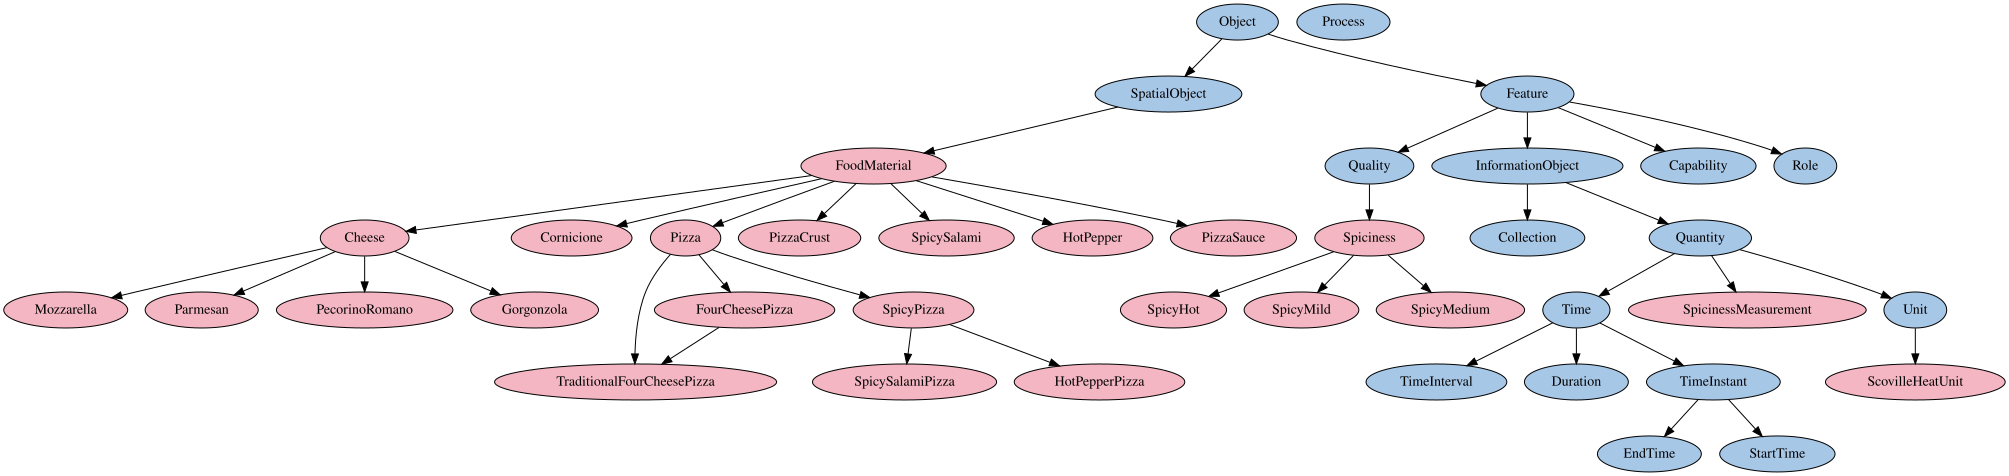

In [11]:
import os
os.makedirs("dist", exist_ok=True)
pizza.save(file="dist/pizza-02.owl", format="rdfxml")
print("Saved pizza-02.owl")
display(get_color_tree([sulo, pizza]))

### **YOUR TURN: Saltiness quality**

The spiciness pattern generalises to any intrinsic characteristic. Apply it to saltiness.

Define `Saltiness` as a `sulo:Quality` with three disjoint levels: `LowSalt`, `MediumSalt`, and `HighSalt`. Define `AnchovyIngredient` as a `FoodMaterial` with `HighSalt` quality. Define `SaltyPizza` as a defined class — a `Pizza` that has a direct part with `HighSalt` quality. Define `AnchovyPizza` with exactly one `AnchovyIngredient` and one `PizzaSauce`.

> Before running the reasoner: will `AnchovyPizza` be classified as a `SaltyPizza`? Trace the reasoning chain.

AnchovyPizza is a subclass of SaltyPizza


### **YOUR TURN: Sodium measurement**

Now extend the saltiness model with a quantitative dimension, mirroring what we did for spiciness.

Define `Milligram` as a `sulo:Unit` and `SodiumMeasurement` as a `sulo:Quantity` that `refersTo` `Saltiness`. Extend `AnchovyIngredient` to also carry a `SodiumMeasurement ≥ 1400` mg. Extend `SaltyPizza.equivalent_to` with a quantitative branch: a pizza is salty if any direct part has `SodiumMeasurement ≥ 1400`. Define `DesaltedAnchovyIngredient` with `SodiumMeasurement ≤ 400` mg and define `DesaltedAnchovyPizza`.

> Will `DesaltedAnchovyPizza` be classified as `SaltyPizza`? Why not — check both branches of the definition.

---

## Summary

This notebook built two parallel arcs — spiciness and saltiness — demonstrating the full quality and quantity modelling workflow in each.

### What we built

| Class | Kind | Key axiom |
|---|---|---|
| `Spiciness`, `SpicyHot`, `SpicyMedium`, `SpicyMild` | Primitive | `SubClassOf sulo:Quality`; `AllDisjoint` levels |
| `SpicySalami` | Primitive | `hasFeature.some(SpicyHot \| SpicyMedium)` |
| `SpicySalamiPizza` | Defined | Closed-world pattern with qualitative ingredient |
| `SpicyPizza` | Defined | `hasDirectPart.some(hasFeature.some(SpicyHot \| SpicyMedium))` + quantitative branch |
| `ScovilleHeatUnit` | Primitive | `SubClassOf sulo:Unit` |
| `SpicinessMeasurement` | Primitive | `SubClassOf sulo:Quantity`; `refersTo.some(Spiciness)` |
| `HotPepper` | Primitive | `hasFeature.some(SpicinessMeasurement & hasValue ≥ 500,000)` |
| `HotPepperPizza` | Defined | Closed-world pattern with quantitative ingredient |
| `Saltiness`, `LowSalt`, `MediumSalt`, `HighSalt` | Primitive | `SubClassOf sulo:Quality`; `AllDisjoint` levels |
| `AnchovyIngredient` | Primitive | `hasFeature.some(HighSalt)` + `SodiumMeasurement ≥ 1400` |
| `Milligram`, `SodiumMeasurement` | Primitive | `SubClassOf sulo:Unit/Quantity`; `refersTo.some(Saltiness)` |
| `SaltyPizza` | Defined | `hasDirectPart.some(hasFeature.some(HighSalt))` + quantitative branch |
| `AnchovyPizza` | Defined | Closed-world pattern; classifies as `SaltyPizza` |
| `DesaltedAnchovyIngredient`, `DesaltedAnchovyPizza` | Primitive/Defined | `SodiumMeasurement ≤ 400`; does not classify as `SaltyPizza` |

### Key concepts

**`sulo:Quality`** — an intrinsic, specifically-dependent feature of an entity that cannot exist independently of it. Categorical levels are declared as disjoint subclasses (`AllDisjoint`) so that no individual can hold two levels simultaneously.

**`hasFeature`** — the SULO property linking an entity to its qualities or quantities. Because `hasDirectPart ⊑ hasPart`, a defined pizza class using `hasDirectPart.some(hasFeature.some(...))` is satisfied by any pizza whose direct ingredient carries the required quality.

**`sulo:Quantity` and `ConstrainedDatatype`** — a quantity pairs a numeric `hasValue` with a `sulo:Unit` and optionally `refersTo` a quality. `ConstrainedDatatype` restricts the value range (`min_inclusive`, `max_inclusive`, etc.).

**The quality–quantity gap** — qualitative and quantitative representations are logically independent under the OWA. An ingredient described only with SHU ≥ 500,000 is *not* automatically `SpicyHot`. The gap is resolved by appending a quantitative branch to the defined class's `equivalent_to`, making either path sufficient for classification.

### What comes next

Notebook 03 introduces **processes** — temporally extended events in which participants are created, transformed, or destroyed. We will model the making of pizza dough, the assembly and baking of a pizza, and the roles played by ingredients and agents in each step.
